# Experiment 3 — Distortion risk and capital estimation

Saved simulated-loss diagnostics, risk measures, capital backtests, contributions and diversification summaries.

In [1]:
from IPython.display import Image, Markdown, display
from mwc_experiments.reporting import load_result_table, result_figure_path

## Simulated loss process

### Simulated losses and regime changes
Inspect clustering, tail episodes and the persistence produced by the simulation design.

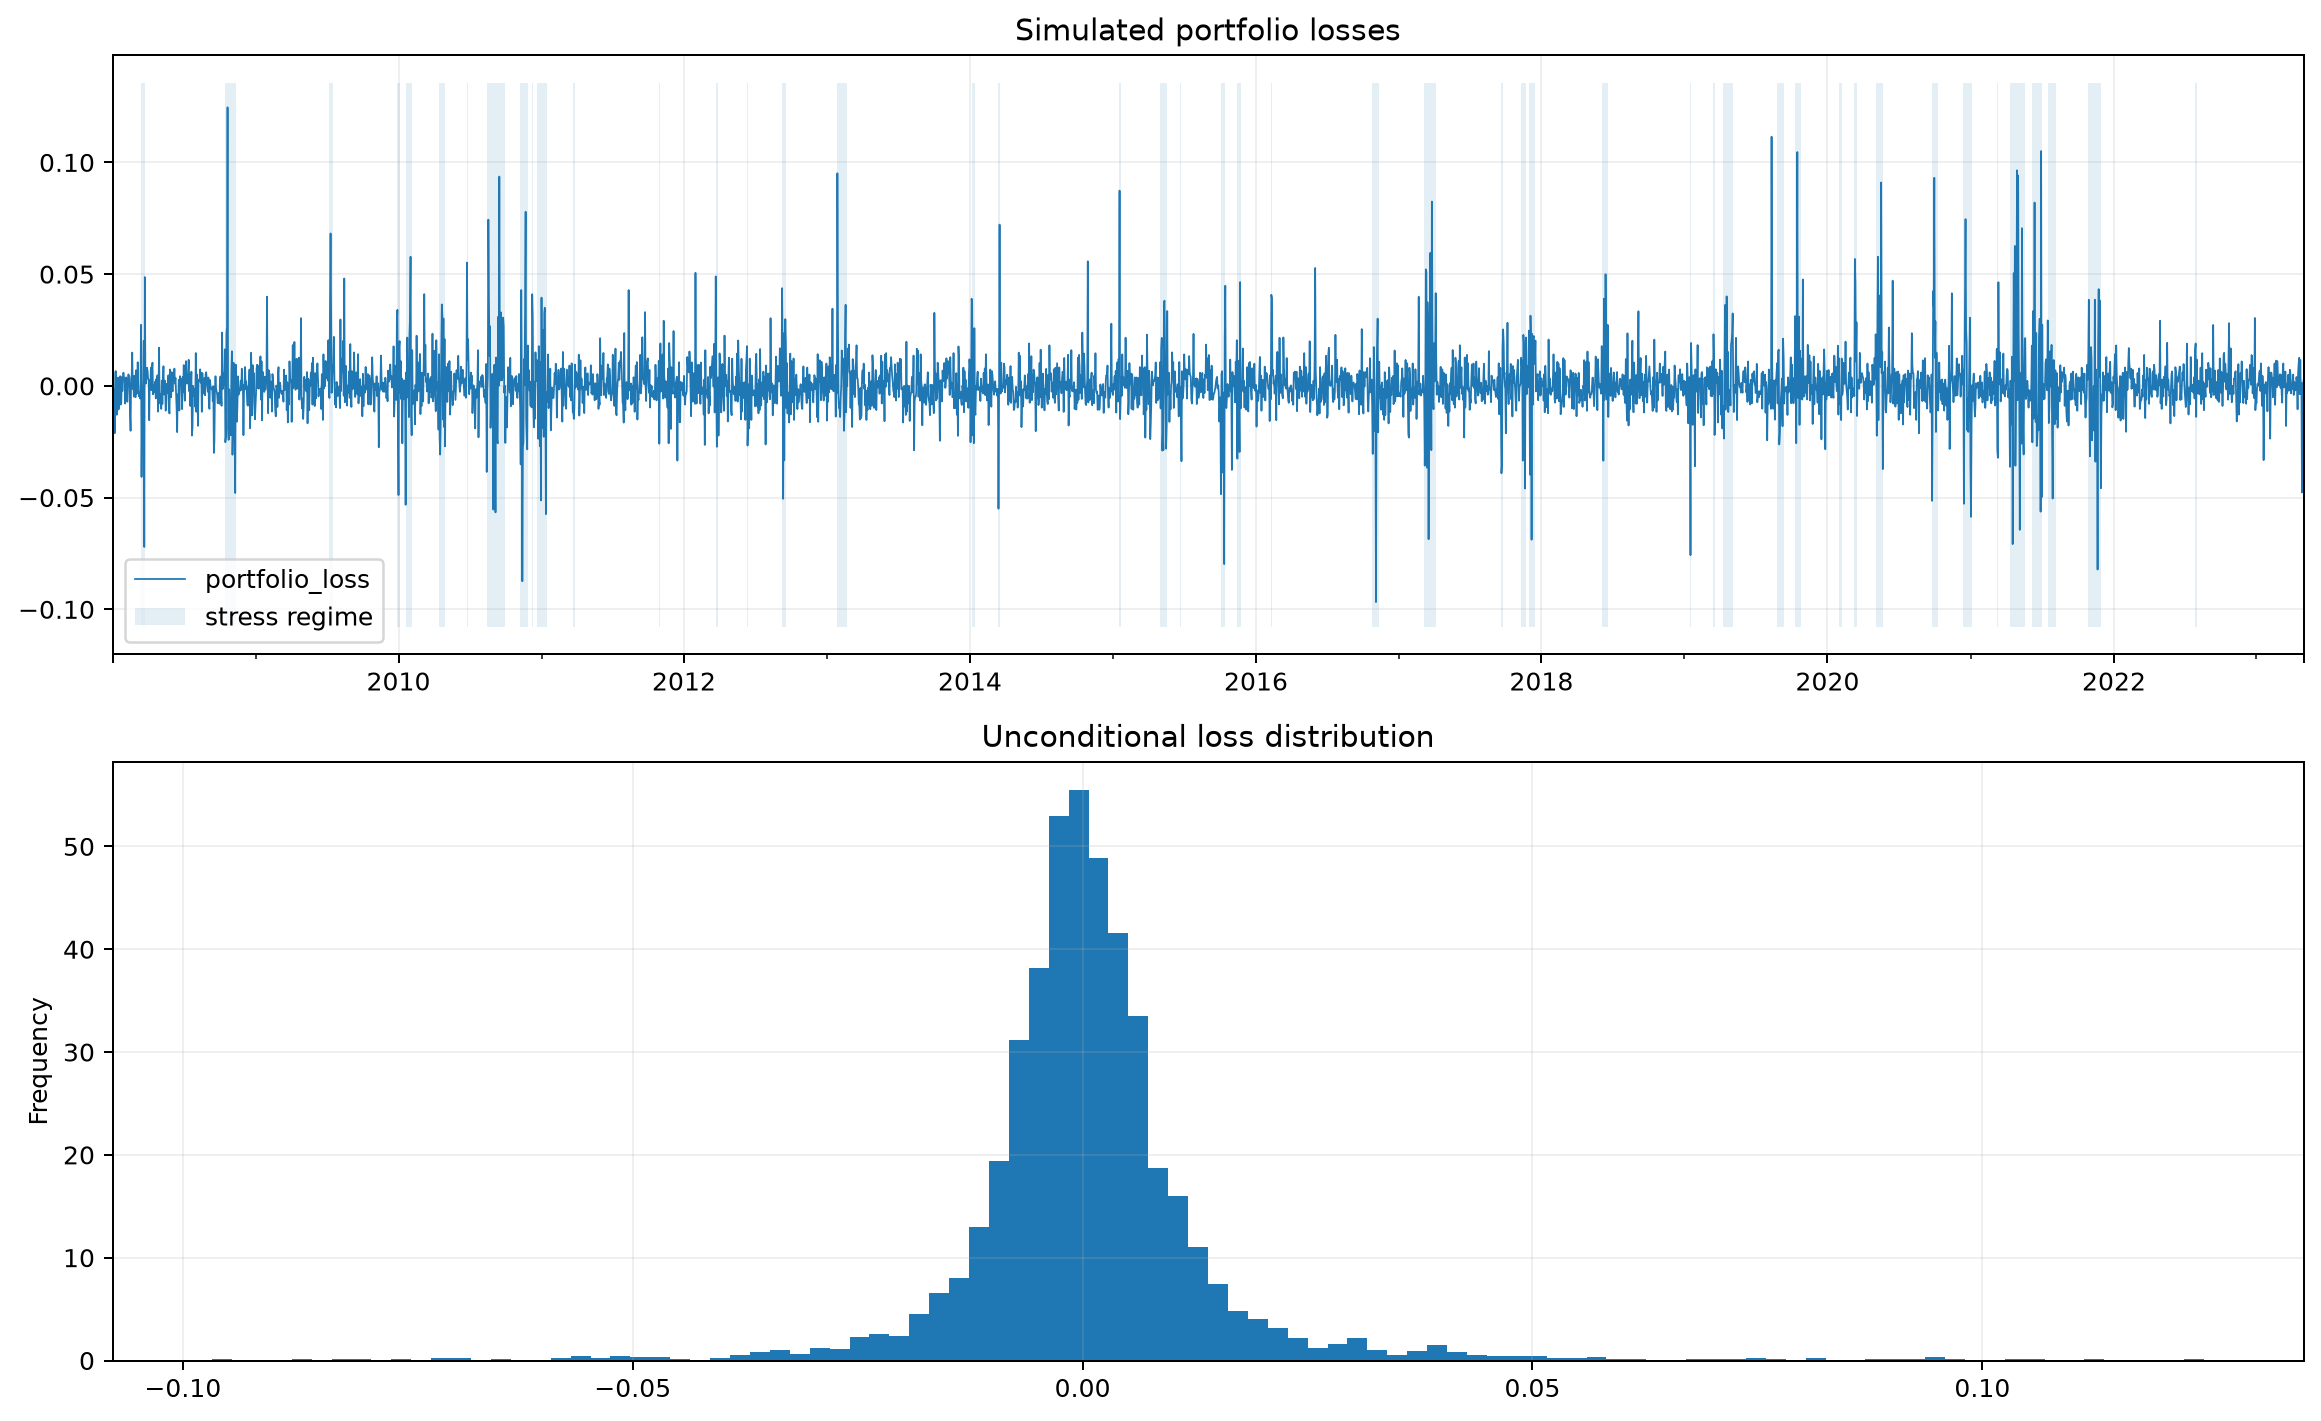

### Regime-dependent correlations
Check how dependence strengthens or changes structure during stressed states.

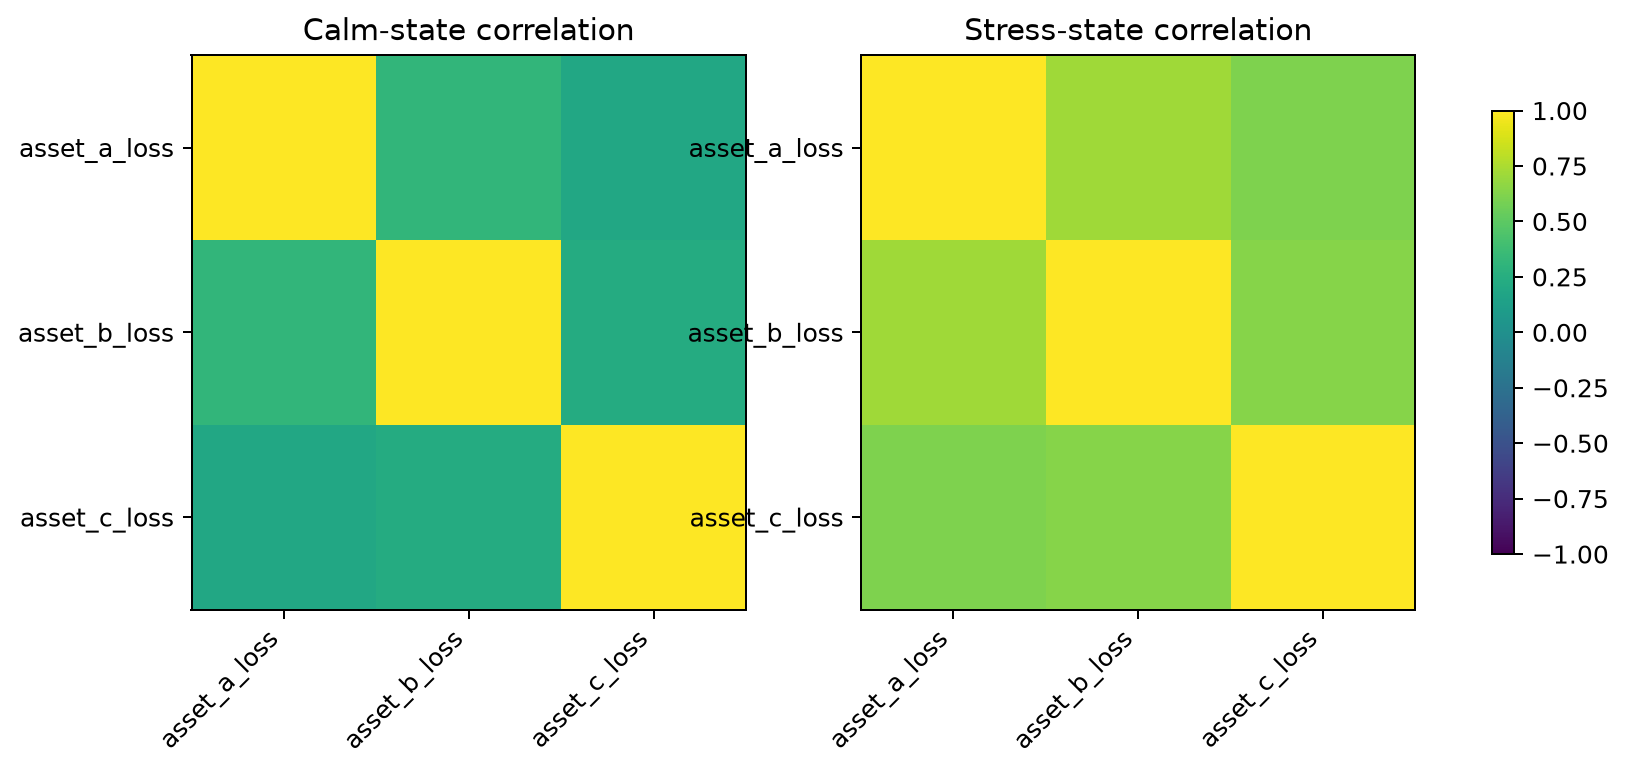

In [2]:
display(Markdown("### Simulated losses and regime changes\nInspect clustering, tail episodes and the persistence produced by the simulation design."))
display(Image(filename=result_figure_path("experiment_3_loss_process.png")))
display(Markdown("### Regime-dependent correlations\nCheck how dependence strengthens or changes structure during stressed states."))
display(Image(filename=result_figure_path("experiment_3_regime_correlations.png")))

## Static capital and ordered contributions

### Static risk and capital measures
Compare VaR, ES and distortion measures across regimes and confidence levels.

capital
measure              parameter            
Identity / mean loss -            0.000537
Proportional hazards gamma=0.85   0.002701
                     gamma=0.7    0.005916
                     gamma=0.5    0.013587
Value-at-Risk        alpha=0.95   0.019188
                     alpha=0.975  0.030081
Expected Shortfall   alpha=0.95   0.036628
Value-at-Risk        alpha=0.99   0.044809
Expected Shortfall   alpha=0.975  0.049751
                     alpha=0.99   0.069772

### Ordered ES contributions
Inspect which components dominate portfolio tail capital after ordering losses.

,loss,increment,capacity,contribution
3980,0.062607,0.003129,0.20,0.000626
3981,0.068205,0.005598,0.19,0.001064
3982,0.070553,0.002348,0.18,0.000423
3983,0.072149,0.001597,0.17,0.000271
3984,0.074369,0.002220,0.16,0.000355
3985,0.074613,0.000243,0.15,0.000036
3986,0.077908,0.003295,0.14,0.000461
3987,0.082037,0.004129,0.13,0.000537
3988,0.082480,0.000443,0.12,0.000053
3989,0.087369,0.004889,0.11,0.000538


### Static-capital visualizations
Use the figures to compare levels and contribution concentration more directly.

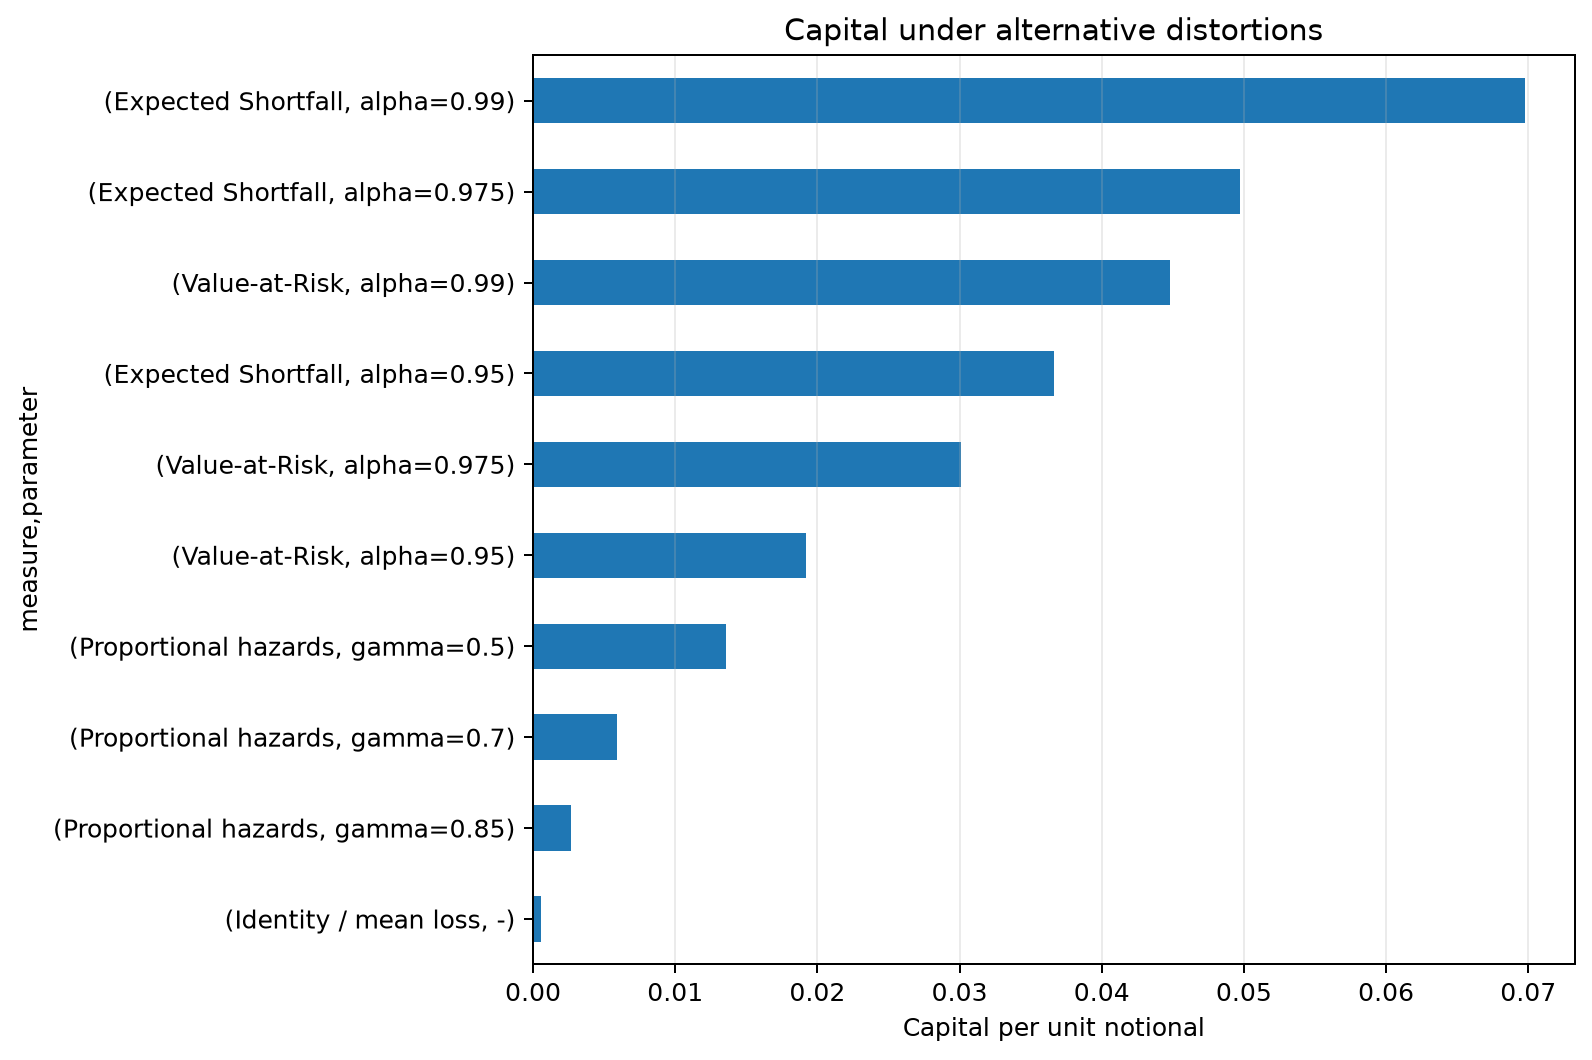

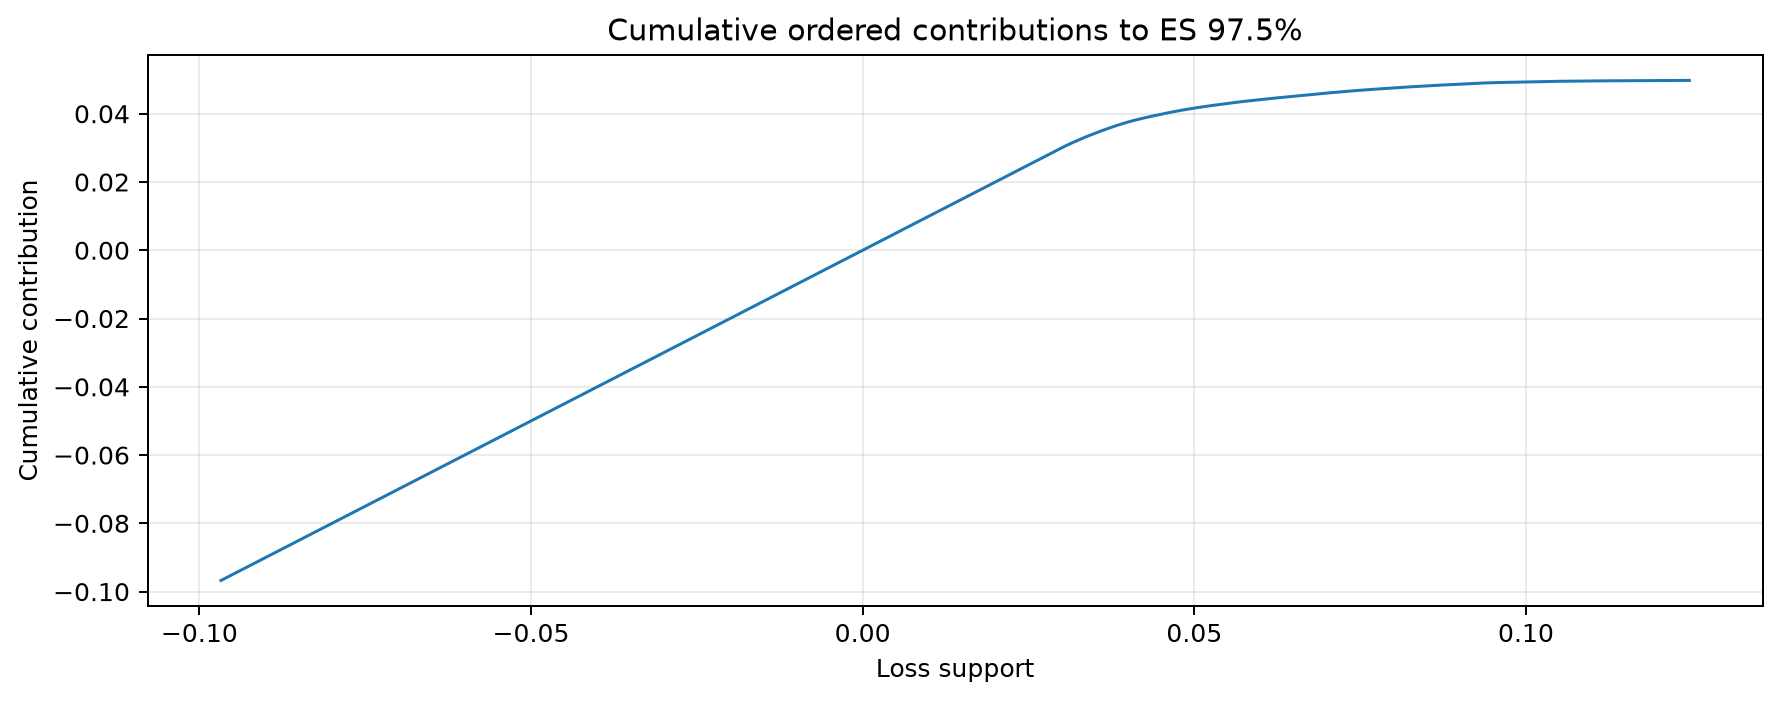

In [3]:
display(Markdown("### Static risk and capital measures\nCompare VaR, ES and distortion measures across regimes and confidence levels."))
display(load_result_table("experiment_3_static_risk_measures.csv", index_col=[0, 1]))
display(Markdown("### Ordered ES contributions\nInspect which components dominate portfolio tail capital after ordering losses."))
display(load_result_table("experiment_3_es_contributions.parquet").tail(20))
display(Markdown("### Static-capital visualizations\nUse the figures to compare levels and contribution concentration more directly."))
display(Image(filename=result_figure_path("experiment_3_static_capital.png")))
display(Image(filename=result_figure_path("experiment_3_es_contributions.png")))

## Rolling capital and backtests

### Capital backtests
Evaluate realized breaches and capital adequacy for each dynamic risk measure.

n_observations  n_exceedances  exceedance_frequency  \
model         sample                                                        
VaR 99%       all               3748             48              0.012807   
              stress             495             37              0.074747   
ES 97.5%      all               3748             38              0.010139   
              stress             495             32              0.064646   
PH gamma=0.70 all               3748            925              0.246798   
              stress             495            223              0.450505   
PH gamma=0.50 all               3748            432              0.115261   
              stress             495            174              0.351515   

                      average_capital  capital_standard_deviation  \
model         sample                                                
VaR 99%       all            0.047167                    0.018261   
              stress         0.056086                    0.020837   
ES 97.5%      all            0.047396                    0.015485   
              stress         0.055312                    0.016958   
PH gamma=0.70 all            0.005669                    0.001799   
              stress         0.006645                    0.001957   
PH gamma=0.50 all            0.012211                    0.003540   
              stress         0.014022                    0.003705   

                      mean_absolute_capital_change  mean_exceedance  \
model         sample                                                  
VaR 99%       all                         0.000191         0.018270   
              stress                      0.001246         0.019137   
ES 97.5%      all                         0.000157         0.021224   
              stress                      0.000971         0.020587   
PH gamma=0.70 all                         0.000059         0.009979   
              stress                      0.000188         0.022547   
PH gamma=0.50 all                         0.000071         0.012154   
              stress                      0.000287         0.020802   

                      maximum_exceedance  total_exceedance  
model         sample                                        
VaR 99%       all               0.078136          0.876963  
              stress            0.068451          0.708069  
ES 97.5%      all               0.080569          0.806499  
              stress            0.060593          0.658794  
PH gamma=0.70 all               0.107825          9.230174  
              stress            0.099175          5.028079  
PH gamma=0.50 all               0.103694          5.250739  
              stress            0.091764          3.619533

### Statistical coverage tests
Check whether exceedance frequencies and independence are consistent with nominal coverage.

statistic   p_value
model   test                                              
VaR 99% Kupiec unconditional coverage   2.739635  0.097887
        Christoffersen independence     8.709345  0.003166

### Stress-regime comparison
Compare capital behavior between normal and stressed simulated periods.

average_capital           exceedance_frequency            \
sample                    all    stress                  all    stress   
model                                                                    
ES 97.5%             0.047396  0.055312             0.010139  0.064646   
PH gamma=0.50        0.012211  0.014022             0.115261  0.351515   
PH gamma=0.70        0.005669  0.006645             0.246798  0.450505   
VaR 99%              0.047167  0.056086             0.012807  0.074747   

              mean_exceedance            
sample                    all    stress  
model                                    
ES 97.5%             0.021224  0.020587  
PH gamma=0.50        0.012154  0.020802  
PH gamma=0.70        0.009979  0.022547  
VaR 99%              0.018270  0.019137

### Rolling-capital visualizations
Inspect the timing of capital changes and their relationship with realized exceptions.

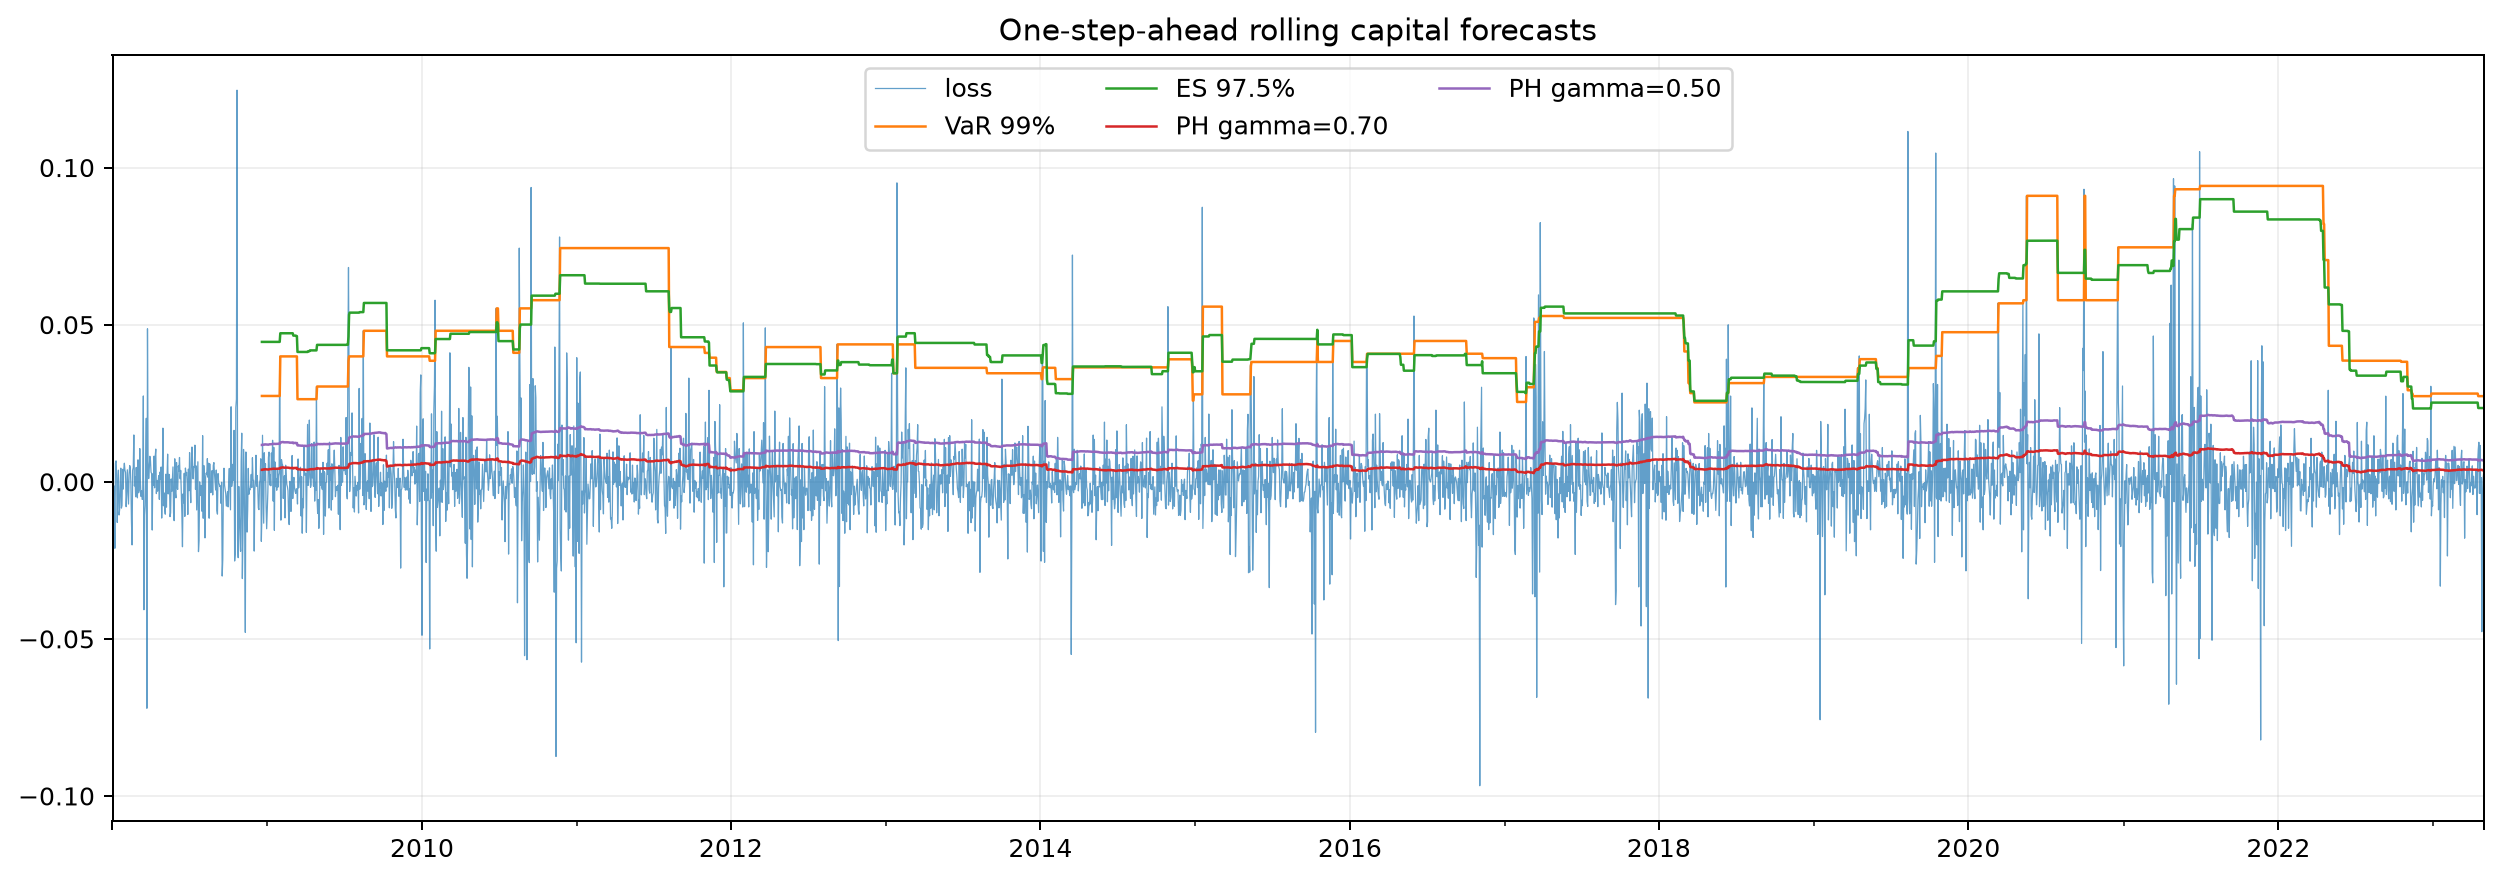

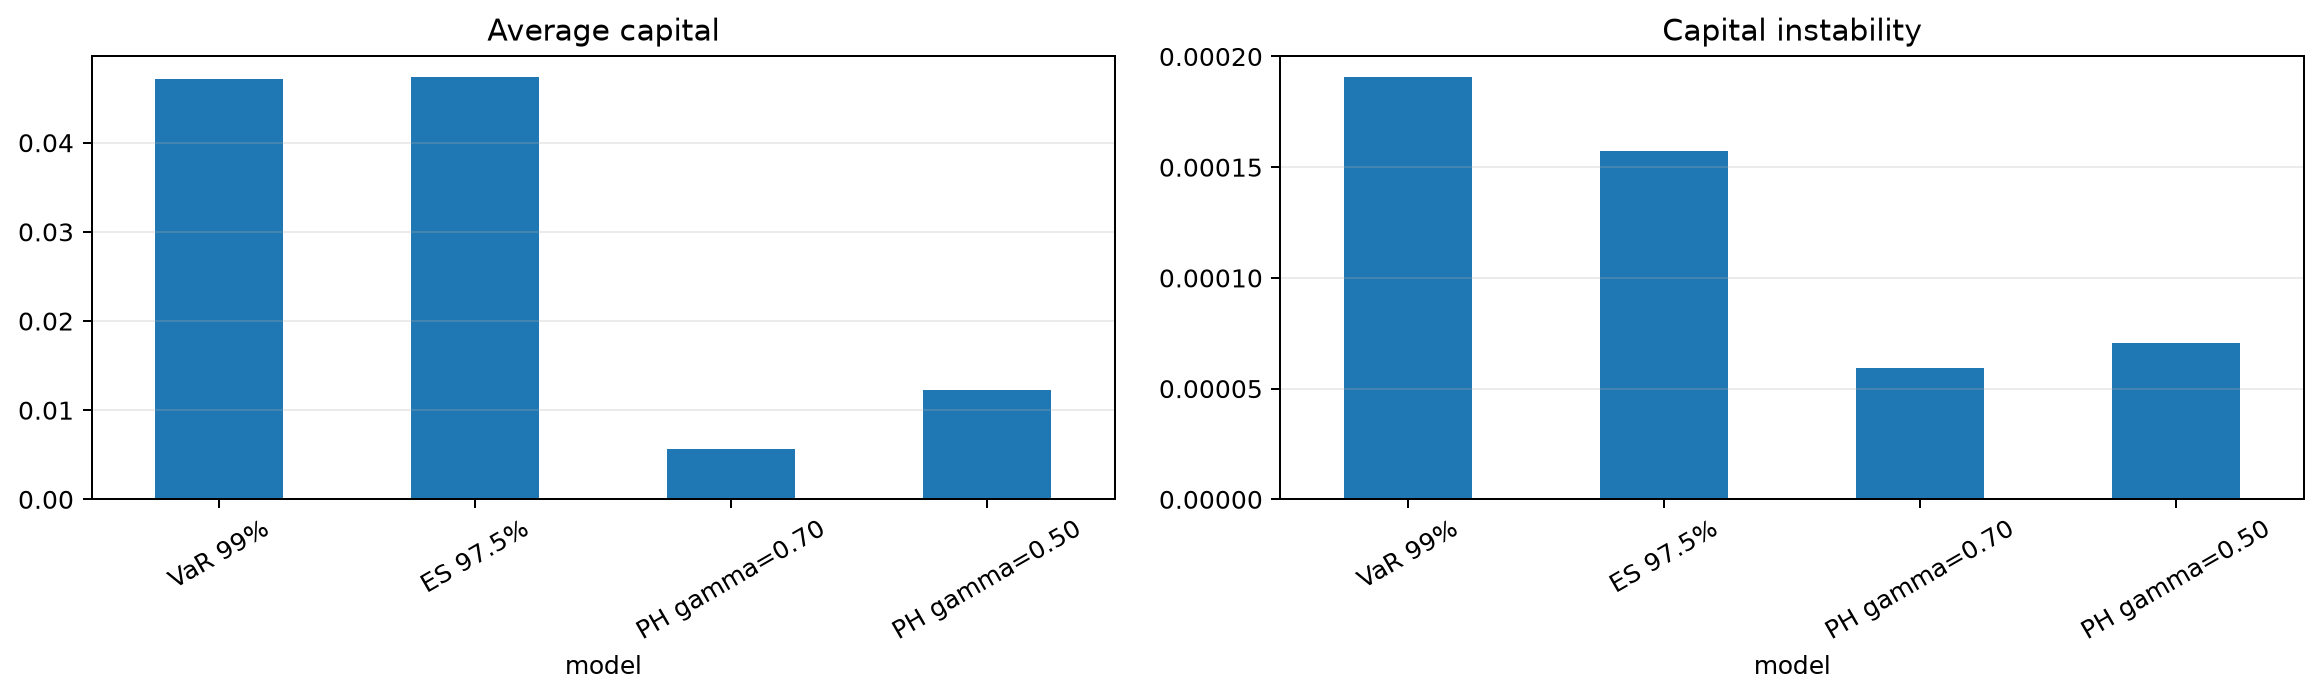

In [4]:
display(Markdown("### Capital backtests\nEvaluate realized breaches and capital adequacy for each dynamic risk measure."))
display(load_result_table("experiment_3_capital_backtests.csv", index_col=[0, 1]))
display(Markdown("### Statistical coverage tests\nCheck whether exceedance frequencies and independence are consistent with nominal coverage."))
display(load_result_table("experiment_3_coverage_tests.csv", index_col=[0, 1]))
display(Markdown("### Stress-regime comparison\nCompare capital behavior between normal and stressed simulated periods."))
display(load_result_table("experiment_3_stress_comparison.csv", index_col=0, header=[0, 1]))
display(Markdown("### Rolling-capital visualizations\nInspect the timing of capital changes and their relationship with realized exceptions."))
display(Image(filename=result_figure_path("experiment_3_rolling_capital.png")))
display(Image(filename=result_figure_path("experiment_3_capital_backtests.png")))

## Diversification and numerical axioms

### Diversification effects
Compare stand-alone and portfolio capital to see how dependence changes diversification benefits.

,rho(A),rho(B),rho(A+B),diversification benefit
measure,,,,
VaR 99%,0.055788,0.045955,0.093805,0.007938
ES 97.5%,0.061965,0.050841,0.104438,0.008368
PH gamma=0.70,0.007550,0.006402,0.012540,0.001412
PH gamma=0.50,0.017194,0.014835,0.028915,0.003114


### Numerical axiom checks
Verify monotonicity, translation behavior and other required properties before interpreting the measures.

,monotonicity,cash_invariance,positive_homogeneity,subadditivity,convexity,comonotonic_additivity
measure,,,,,,
ES 97.5%,True,True,True,True,True,NaN
PH gamma=0.70,True,True,True,True,True,NaN
PH gamma=1.20,True,True,True,False,False,NaN


### Diversification visualization
The chart highlights differences that are harder to compare across table rows.

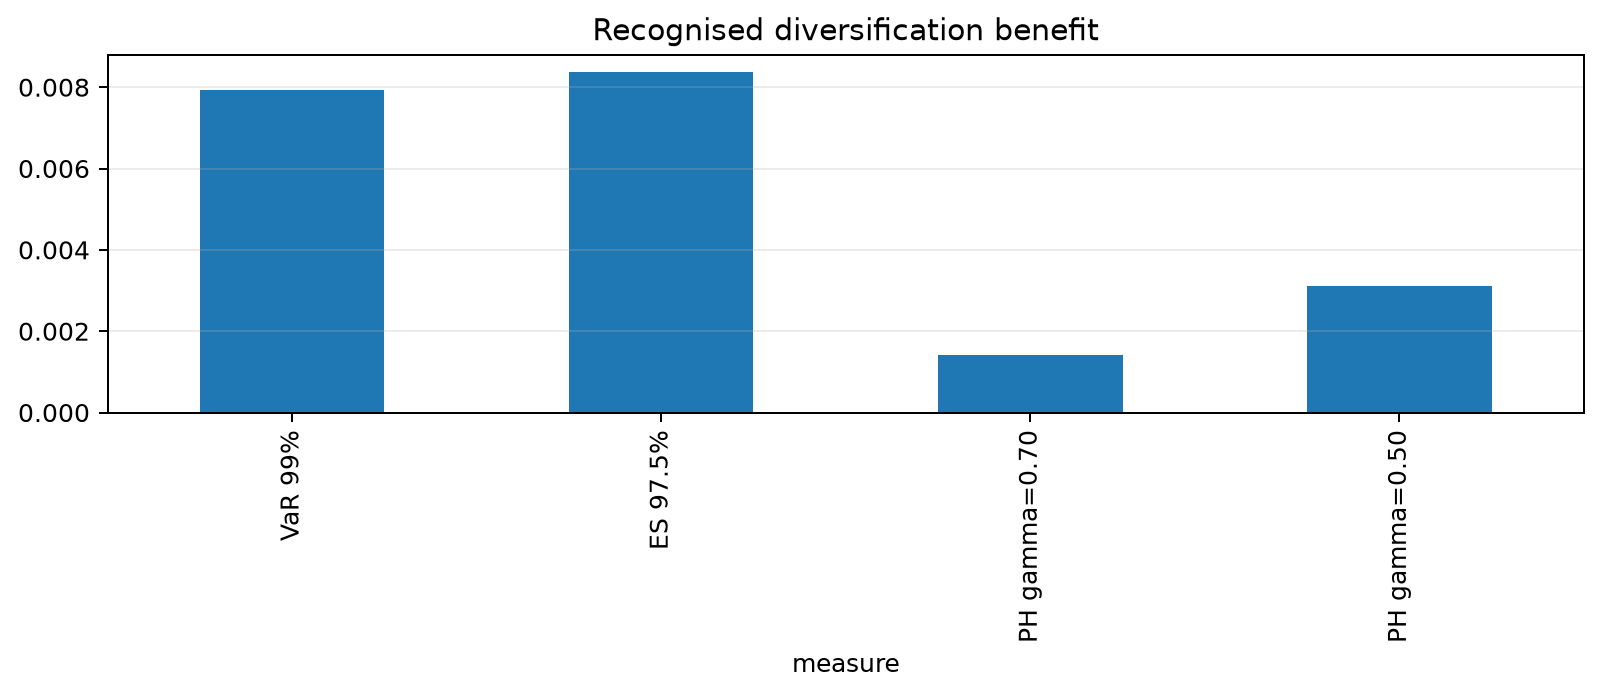

In [5]:
display(Markdown("### Diversification effects\nCompare stand-alone and portfolio capital to see how dependence changes diversification benefits."))
display(load_result_table("experiment_3_diversification.csv", index_col=0))
display(Markdown("### Numerical axiom checks\nVerify monotonicity, translation behavior and other required properties before interpreting the measures."))
display(load_result_table("experiment_3_axiom_checks.csv", index_col=0))
display(Markdown("### Diversification visualization\nThe chart highlights differences that are harder to compare across table rows."))
display(Image(filename=result_figure_path("experiment_3_diversification.png")))